# TRQuant 系统架构与工作流程

> **版本**: v4.4  
> **更新**: 2026-01-02  

---

In [1]:
import graphviz

# Dark Mode 颜色 (彩色版)
BG = '#1E1E1E'
EDGE = '#888888'
TEXT = '#FFFFFF'
BORDER = '#444444'

# 模块颜色
LIVE = '#D84315'       # 橙色 - 实战阶段
LIVE_BG = '#2A1008'
RESEARCH = '#6A1B9A'   # 紫色 - 研究阶段
RESEARCH_BG = '#1A0825'
KB = '#00838F'         # 青色 - 知识库
KB_BG = '#001A1C'
BRIDGE = '#455A64'     # 灰蓝色 - 转换层
BRIDGE_BG = '#1A2226'
SUCCESS = '#2E7D32'    # 绿色 - 成功

print('✅ 环境准备完成')

✅ 环境准备完成


---

## 系统架构总览

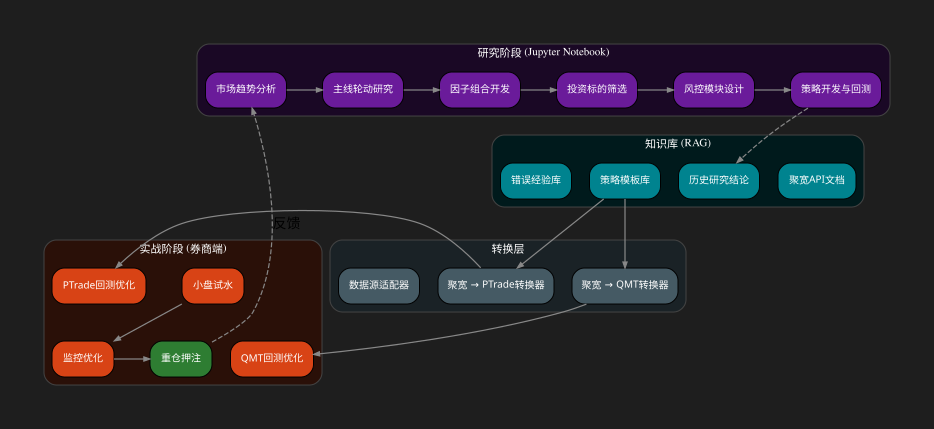

In [ ]:
# 系统架构总览图 - 严格按照参考图布局
dot = graphviz.Digraph(format='svg')
dot.attr(bgcolor=BG, fontcolor=TEXT, pad='0.5')
dot.attr('node', shape='box', style='filled,rounded', fontname='SimHei',
         fontcolor=TEXT, fontsize='10', margin='0.15,0.08')
dot.attr('edge', color=EDGE, penwidth='1.2', arrowsize='0.6')

# ========== 实战阶段 (券商端) - 顶部 ==========
with dot.subgraph(name='cluster_live') as c:
    c.attr(label='实战阶段 (券商端)', labelloc='t', fontsize='11',
           style='rounded', color=BORDER, fontcolor=TEXT, bgcolor=LIVE_BG)
    # 左列
    c.node('L_pt', 'PTrade回测优化', fillcolor=LIVE)
    c.node('L_qmt', 'QMT回测优化', fillcolor=LIVE)
    # 右列
    c.node('L_trial', '小盘试水', fillcolor=LIVE)
    c.node('L_monitor', '监控优化', fillcolor=LIVE)
    c.node('L_full', '重仓押注', fillcolor=SUCCESS)刚
    # 布局
    c.body.append('{rank=same; L_pt; L_trial}')
    c.body.append('{rank=same; L_qmt; L_monitor; L_full}')
    # 内部连接
    c.edge('L_pt', 'L_trial', style='invis')  # 对齐用
    c.edge('L_qmt', 'L_trial', style='invis')  # 对齐用
    c.edge('L_trial', 'L_monitor')
    c.edge('L_monitor', 'L_full')

# ========== 研究阶段 (Jupyter Notebook) - 中部 ==========
with dot.subgraph(name='cluster_research') as c:
    c.attr(label='研究阶段 (Jupyter Notebook)', labelloc='t', fontsize='11',
           style='rounded', color=BORDER, fontcolor=TEXT, bgcolor=RESEARCH_BG)
    c.node('R1', '市场趋势分析', fillcolor=RESEARCH)
    c.node('R2', '主线轮动研究', fillcolor=RESEARCH)
    c.node('R3', '因子组合开发', fillcolor=RESEARCH)
    c.node('R4', '投资标的筛选', fillcolor=RESEARCH)
    c.node('R5', '风控模块设计', fillcolor=RESEARCH)
    c.node('R6', '策略开发与回测', fillcolor=RESEARCH)
    # 横向排列
    c.body.append('{rank=same; R1; R2; R3; R4; R5; R6}')
    # 内部连接
    c.edge('R1', 'R2')
    c.edge('R2', 'R3')
    c.edge('R3', 'R4')
    c.edge('R4', 'R5')
    c.edge('R5', 'R6')

# ========== 知识库 (RAG) - 左下 ==========
with dot.subgraph(name='cluster_kb') as c:
    c.attr(label='知识库 (RAG)', labelloc='t', fontsize='11',
           style='rounded', color=BORDER, fontcolor=TEXT, bgcolor=KB_BG)
    c.node('K1', '聚宽API文档', fillcolor=KB)
    c.node('K2', '历史研究结论', fillcolor=KB)
    c.node('K3', '策略模板库', fillcolor=KB)
    c.node('K4', '错误经验库', fillcolor=KB)

# ========== 转换层 - 右下 ==========
with dot.subgraph(name='cluster_bridge') as c:
    c.attr(label='转换层', labelloc='t', fontsize='11',
           style='rounded', color=BORDER, fontcolor=TEXT, bgcolor=BRIDGE_BG)
    c.node('B1', '聚宽 → PTrade转换器', fillcolor=BRIDGE)
    c.node('B2', '聚宽 → QMT转换器', fillcolor=BRIDGE)
    c.node('B3', '数据源适配器', fillcolor=BRIDGE)

# ========== 跨模块连接 ==========
# 实战 → 研究 (反馈，大弧线)
dot.edge('L_full', 'R1', style='dashed', label='反馈')

# 研究 → 知识库
dot.edge('R6', 'K2', style='dashed')

# 知识库 → 转换层
dot.edge('K3', 'B1')
dot.edge('K3', 'B2')

# 转换层 → 实战
dot.edge('B1', 'L_pt')
dot.edge('B2', 'L_qmt')

dot

### 架构说明

| 模块 | 颜色 | 职责 |
|------|------|------|
| **实战阶段** | 🟠 橙色 | 券商端执行：PTrade/QMT回测→小盘试水→监控优化→重仓押注 |
| **研究阶段** | 🟣 紫色 | Jupyter研发：市场分析→主线→因子→选股→风控→回测 |
| **知识库** | 🔵 青色 | RAG支持：API文档、研究结论、模板库、经验库 |
| **转换层** | ⬛ 灰色 | 代码转换：聚宽→PTrade/QMT，数据源适配 |

---

## 研究阶段详细流程

In [ ]:
# 研究阶段流程
dot = graphviz.Digraph(format='svg')
dot.attr(rankdir='LR', bgcolor=BG, fontcolor=TEXT,
         nodesep='0.4', ranksep='0.5', margin='0.2',
         label='研究阶段详细流程', labelloc='t', fontsize='12')
dot.attr('node', shape='box', style='filled,rounded', fontname='SimHei',
         fontcolor=TEXT, fontsize='9', margin='0.1,0.05')
dot.attr('edge', color=EDGE, penwidth='1.2', arrowsize='0.6')

dot.node('S', '开始', fillcolor=SUCCESS, shape='ellipse')
dot.node('A', '① 数据检测', fillcolor=KB)
dot.node('B', '② 市场分析', fillcolor=RESEARCH)
dot.node('C', '③ 主线识别', fillcolor=RESEARCH)
dot.node('D', '④ 因子研究', fillcolor=RESEARCH)
dot.node('E', '⑤ 标的筛选', fillcolor=RESEARCH)
dot.node('F', '⑥ 策略回测', fillcolor=RESEARCH)
dot.node('G', '通过?', fillcolor='#F9A825', shape='diamond')
dot.node('Z', '入库', fillcolor=SUCCESS, shape='ellipse')

dot.edge('S', 'A')
dot.edge('A', 'B')
dot.edge('B', 'C')
dot.edge('C', 'D')
dot.edge('D', 'E')
dot.edge('E', 'F')
dot.edge('F', 'G')
dot.edge('G', 'Z', label='是')
dot.edge('G', 'D', label='否', style='dashed', constraint='false')

dot

---

## 实战阶段详细流程

In [ ]:
# 实战阶段流程
dot = graphviz.Digraph(format='svg')
dot.attr(rankdir='LR', bgcolor=BG, fontcolor=TEXT,
         nodesep='0.4', ranksep='0.5', margin='0.2',
         label='实战阶段详细流程', labelloc='t', fontsize='12')
dot.attr('node', shape='box', style='filled,rounded', fontname='SimHei',
         fontcolor=TEXT, fontsize='9', margin='0.1,0.05')
dot.attr('edge', color=EDGE, penwidth='1.2', arrowsize='0.6')

dot.node('A', '策略转换', fillcolor=BRIDGE)
dot.node('B', '券商回测', fillcolor=LIVE)
dot.node('C', '小盘试水\n(10%仓位)', fillcolor=LIVE)
dot.node('D', '监控优化', fillcolor=LIVE)
dot.node('E', '加仓\n(30%仓位)', fillcolor=LIVE)
dot.node('F', '重仓押注\n(50%+)', fillcolor=SUCCESS)

dot.edge('A', 'B')
dot.edge('B', 'C')
dot.edge('C', 'D')
dot.edge('D', 'E')
dot.edge('E', 'F')
dot.edge('D', 'A', style='dashed', label='优化', constraint='false')

dot

---

## 核心模块说明

### 🟣 研究阶段
| 模块 | Notebook | 功能 |
|------|----------|------|
| 市场趋势分析 | `01_market_trend_comprehensive.ipynb` | 判断牛熊震荡 |
| 主线轮动研究 | `02_ibd_reversal_analysis.ipynb` | 识别领涨板块 |
| 因子组合开发 | `04_factor_research.ipynb` | IC/IR分析 |
| 策略开发与回测 | `strategies/` | 信号生成+回测 |

### ⬛ 转换层
| 模块 | 位置 | 功能 |
|------|------|------|
| PTrade转换器 | `ptrade_bridge/` | 聚宽→PTrade |
| QMT转换器 | `qmt_bridge/` | 聚宽→QMT |
| 数据源适配器 | `data_sources/` | 统一数据接口 |

### 🔵 知识库
| 模块 | 位置 | 功能 |
|------|------|------|
| 聚宽API文档 | `docs/jqdata/` | API参考 |
| 策略模板库 | `strategies/templates/` | 可复用策略 |
| 错误经验库 | MCP xuanyuan | 问题解决记录 |

---

## 📝 下一步

- 市场分析: `01_market_trend_comprehensive.ipynb`
- 可视化: `06_market_visualization.ipynb`